# 成交额斜率因子 Alphalens 分析

本 Notebook 用于分析项目中的 `ASP / Volume Slope` 因子是否具备横截面选股能力。

因子定义：

```text
factor = rolling LINEARREG_SLOPE(total_turnover, window)
```

也就是对每只股票最近 `window` 个交易日的成交额 `total_turnover` 做线性回归，并取斜率作为因子值。

本 Notebook 会完成：

1. 读取 `prepare_cn_stock_data_rq.py` 生成的本地缓存数据。
2. 计算成交额斜率因子。
3. 构造 Alphalens 所需的 `factor` 和 `prices` 输入。
4. 计算不同持有期的 IC、Rank IC、分位数组合收益。
5. 分析因子分组收益、分组单调性、Top/Bottom 组换手。
6. 导出分析结果，方便后续和 vectorbt 回测结果交叉验证。

注意：Alphalens 原项目维护较慢，在部分 Python 环境中可能安装困难。因此本 Notebook 同时提供了 Alphalens 路径和 Pandas 备用分析路径。

## 0. 环境准备

如果当前环境没有安装 `alphalens`，可以先尝试：

```bash
pip install alphalens-reloaded
```

如果安装失败，也可以继续运行 Notebook。后面的 Pandas 备用分析代码仍然可以输出核心 IC 和分位收益结果。

In [1]:
# 基础库：用于数据处理、数值计算和画图
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 在 Notebook 中直接显示图表
%matplotlib inline

# 让表格显示更完整，便于检查宽表数据
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Alphalens 是可选依赖：如果导入失败，后续会走备用分析逻辑
try:
    import alphalens as al
    HAS_ALPHALENS = True
    print("Alphalens 已导入，可以运行标准 Alphalens tear sheet。")
except Exception as exc:
    HAS_ALPHALENS = False
    print(f"Alphalens 不可用，将使用 Pandas 备用分析。原因：{type(exc).__name__}: {exc}")

warnings.filterwarnings("ignore")

Alphalens 已导入，可以运行标准 Alphalens tear sheet。


## 1. 参数配置

这里的日期必须和 `prepare_cn_stock_data_rq.py` 生成的缓存文件名一致。

例如如果缓存文件是：

```text
data_rq/cn_stock_close_20200101_20260429.parquet
data_rq/cn_stock_total_turnover_20200101_20260429.parquet
```

那么 `START_DATE` 就应为 `2020-01-01`，`END_DATE` 就应为 `2026-04-29`。

In [ ]:
# 数据缓存目录：由 prepare_cn_stock_data_rq.py 生成
DATA_DIR = Path("data_rq")

# 这里填写已经下载好的缓存日期区间
START_DATE = "2020-01-01"
END_DATE = "2026-04-29"

# 成交额斜率窗口。建议先从 20 或 60 开始分析，再对多个窗口循环比较
FACTOR_WINDOW = 20

# Alphalens / 因子分析常用的未来收益观察窗口
FORWARD_PERIODS = (1, 5, 10, 20)

# 分位数组数：5 组更稳，10 组更细
QUANTILES = 5

# 为了快速试跑，可以限制股票数量；正式分析时设为 None
MAX_ASSETS = None

# 输出目录
OUTPUT_DIR = Path("results/alphalens_volume_slope")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("数据目录：", DATA_DIR.resolve())
print("结果目录：", OUTPUT_DIR.resolve())

## 2. 读取本地缓存数据

本项目的数据缓存是宽表格式：

```text
index: 交易日期
columns: 股票代码
values: open / close / total_turnover
```

Alphalens 需要两个核心输入：

1. `factor`：MultiIndex Series，索引为 `(date, asset)`。
2. `prices`：宽表价格矩阵，索引为 `date`，列为 `asset`。

In [ ]:
def matrix_path(data_dir: Path, field: str, start_date: str, end_date: str) -> Path:
    """Return the required parquet cache path for a date x stock matrix."""
    stem = f"cn_stock_{field}_{start_date.replace('-', '')}_{end_date.replace('-', '')}"
    parquet_path = data_dir / f"{stem}.parquet"
    if parquet_path.exists():
        return parquet_path
    raise FileNotFoundError(f"Missing {field} parquet cache: {parquet_path}")


def read_matrix(data_dir: Path, field: str, start_date: str, end_date: str) -> pd.DataFrame:
    """Read a parquet date x stock matrix and normalize index/column order."""
    path = matrix_path(data_dir, field, start_date, end_date)
    print(f"Reading {field}: {path}")
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.sort_index().sort_index(axis=1)




close = read_matrix(DATA_DIR, "close", START_DATE, END_DATE)
turnover = read_matrix(DATA_DIR, "total_turnover", START_DATE, END_DATE)

# 对齐两个矩阵的股票列，避免价格有但成交额没有，或反过来的情况
common_assets = close.columns.intersection(turnover.columns)
if MAX_ASSETS is not None:
    common_assets = common_assets[:MAX_ASSETS]

close = close.loc[:, common_assets]
turnover = turnover.loc[:, common_assets]

print("close shape:", close.shape)
print("turnover shape:", turnover.shape)
display(close.head())

## 3. 计算成交额斜率因子

这里复刻策略中的 `LINEARREG_SLOPE(total_turnover, window)`。

对窗口内的成交额序列：

```text
y = [turnover_1, turnover_2, ..., turnover_N]
x = [0, 1, ..., N-1]
```

计算 `y` 对 `x` 的线性回归斜率。

斜率越大，说明最近成交额上升越明显；斜率越小，说明成交额下降越明显。

In [4]:
def calc_linearreg_slope(values: pd.DataFrame, window: int) -> pd.DataFrame:
    """计算宽表数据的滚动线性回归斜率。

    说明：
    - 输入 values 是日期 x 股票的宽表。
    - 输出 slope 形状与输入一致。
    - 前 window-1 天因为数据不足，会是 NaN。
    """
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    denominator = ((x - x_mean) ** 2).sum()

    def slope_one_window(y):
        # rolling.apply 会把每个窗口的一维数组传进来
        if np.isnan(y).any():
            return np.nan
        y_mean = y.mean()
        return ((x - x_mean) * (y - y_mean)).sum() / denominator

    return values.rolling(window, min_periods=window).apply(slope_one_window, raw=True)


# 计算原始成交额斜率因子
factor_wide_raw = calc_linearreg_slope(turnover, FACTOR_WINDOW)

# 横截面标准化：去掉量纲影响，便于不同股票之间排序
# 如果你想完全使用原始斜率，也可以把后续 factor_wide 改为 factor_wide_raw
factor_wide = factor_wide_raw.sub(factor_wide_raw.mean(axis=1), axis=0)
factor_wide = factor_wide.div(factor_wide.std(axis=1), axis=0)

# 将无穷值替换为 NaN，避免后续分位数和相关系数异常
factor_wide = factor_wide.replace([np.inf, -np.inf], np.nan)

print("factor shape:", factor_wide.shape)
display(factor_wide.tail())

factor shape: (1530, 5114)


,000001.XSHE,000002.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,...,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-22,-0.522581,-0.192661,-0.165078,-0.154016,-0.873797,-0.156756,-0.139022,-0.188228,-0.223234,-0.476921,-0.122661,-0.153958,-0.220404,-0.598366,-0.795138,...,-0.175531,0.862987,0.643236,-0.152279,-0.145626,-0.260616,-0.161997,-0.218826,-0.344861,0.018141,-0.372853,0.220337,-0.225165,3.012044,-0.398740
2026-04-23,-0.557344,-0.216498,-0.136163,-0.190406,-1.069105,-0.165264,-0.168491,-0.220489,-0.231029,-0.467801,-0.168233,-0.178148,-0.203585,-0.469716,-0.337155,...,-0.197727,0.730932,0.715514,-0.155260,-0.169387,-0.263036,-0.188170,-0.278670,-0.338798,0.006814,-0.500403,0.291588,-0.251367,2.758323,-0.309037
2026-04-24,-0.543633,-0.232865,-0.065257,-0.200188,-1.215194,-0.149880,-0.192407,-0.215808,-0.222688,-0.431055,-0.206827,-0.176630,-0.163035,-0.391975,-0.156078,...,-0.196235,0.585389,0.683470,-0.087899,-0.171345,-0.210205,-0.196578,-0.308984,-0.306315,0.032688,-0.577165,0.221640,-0.234866,4.068764,-0.235882
2026-04-27,0.464483,-0.296485,-0.054058,-0.209830,-1.470999,-0.133463,-0.181692,-0.215883,-0.226815,-0.385151,-0.216436,-0.176719,-0.200602,-0.341971,-0.006102,...,-0.209589,0.998874,0.643203,-0.056713,-0.178461,-0.208034,-0.188652,-0.340361,-0.287551,0.040447,-0.526562,0.143014,-0.221629,5.727267,-0.257551
2026-04-28,0.742424,-0.326005,-0.100754,-0.205410,-1.731121,-0.131311,-0.213999,-0.218415,-0.160604,-0.370897,-0.259106,-0.182696,-0.165693,-0.337503,-0.076550,...,-0.225326,1.238324,0.593131,0.010123,-0.153293,-0.173625,-0.194136,-0.393340,-0.276911,0.092531,-0.551658,0.110246,-0.222041,6.443852,-0.242238


## 4. 构造 Alphalens 输入格式

Alphalens 的 `factor` 要求是一个 MultiIndex Series：

```text
date        asset
2020-01-02  000001.XSHE    0.53
2020-01-02  000002.XSHE   -0.21
...
```

而 `prices` 仍然使用宽表 `close`。

In [5]:
# stack 后得到 MultiIndex Series，索引层级为 date / asset
factor_series = factor_wide.stack(dropna=True)
factor_series.index = factor_series.index.set_names(["date", "asset"])
factor_series.name = "volume_slope_zscore"

# Alphalens 对日期索引比较敏感，统一去掉时区信息
close.index = close.index.tz_localize(None)
factor_series.index = pd.MultiIndex.from_arrays(
    [factor_series.index.get_level_values("date").tz_localize(None), factor_series.index.get_level_values("asset")],
    names=["date", "asset"],
)

print("factor observations:", len(factor_series))
display(factor_series.head())

factor observations: 6960563


date        asset      
2020-02-06  000001.XSHE    1.160986
            000002.XSHE    1.448498
            000006.XSHE   -0.145076
            000007.XSHE    0.185196
            000008.XSHE   -0.205621
Name: volume_slope_zscore, dtype: float64

## 5. 标准 Alphalens 分析

如果当前环境安装了 Alphalens，这一节会生成标准 tear sheet。

核心关注：

- IC 均值是否稳定为正或为负。
- IC 的 t 值是否显著。
- 分位数组合收益是否单调。
- Top 组和 Bottom 组收益差是否稳定。
- 因子换手是否过高。

In [6]:
if HAS_ALPHALENS:
    # get_clean_factor_and_forward_returns 会自动计算未来收益、分位数，并清理缺失值
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=factor_series,
        prices=close,
        periods=FORWARD_PERIODS,
        quantiles=QUANTILES,
        max_loss=0.5,
    )

    print("Alphalens factor_data shape:", factor_data.shape)
    display(factor_data.head())

    # 保存清洗后的 factor_data，便于复查和复用
    factor_data.to_csv(OUTPUT_DIR / f"factor_data_window_{FACTOR_WINDOW}.csv", encoding="utf-8-sig")
else:
    print("Alphalens 不可用，跳过 factor_data 构造。")

Dropped 1.5% entries from factor data: 1.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 50.0%, not exceeded: OK!
Alphalens factor_data shape: (6858280, 6)


1D        5D       10D       20D    factor  factor_quantile
date       asset                                                                         
2020-02-06 000001.XSHE -0.010156 -0.008125  0.055518  0.041977  1.160986                5
           000002.XSHE -0.014337  0.073477  0.069892  0.157706  1.448498                5
           000006.XSHE -0.008772  0.021930  0.070175  0.116228 -0.145076                2
           000007.XSHE  0.029932  0.104762  0.112925  0.232653  0.185196                5
           000008.XSHE  0.000000  0.019672  0.081967  0.144262 -0.205621                2

Information Analysis


,1D,5D,10D,20D
IC Mean,-0.028,-0.034,-0.038,-0.042
IC Std.,0.111,0.102,0.096,0.095
Risk-Adjusted IC,-0.254,-0.332,-0.392,-0.443
t-stat(IC),-9.813,-12.839,-15.150,-17.120
p-value(IC),0.000,0.000,0.000,0.000
IC Skew,0.101,-0.147,-0.090,-0.236
IC Kurtosis,0.160,0.398,0.199,-0.057


<Figure size 640x480 with 0 Axes>

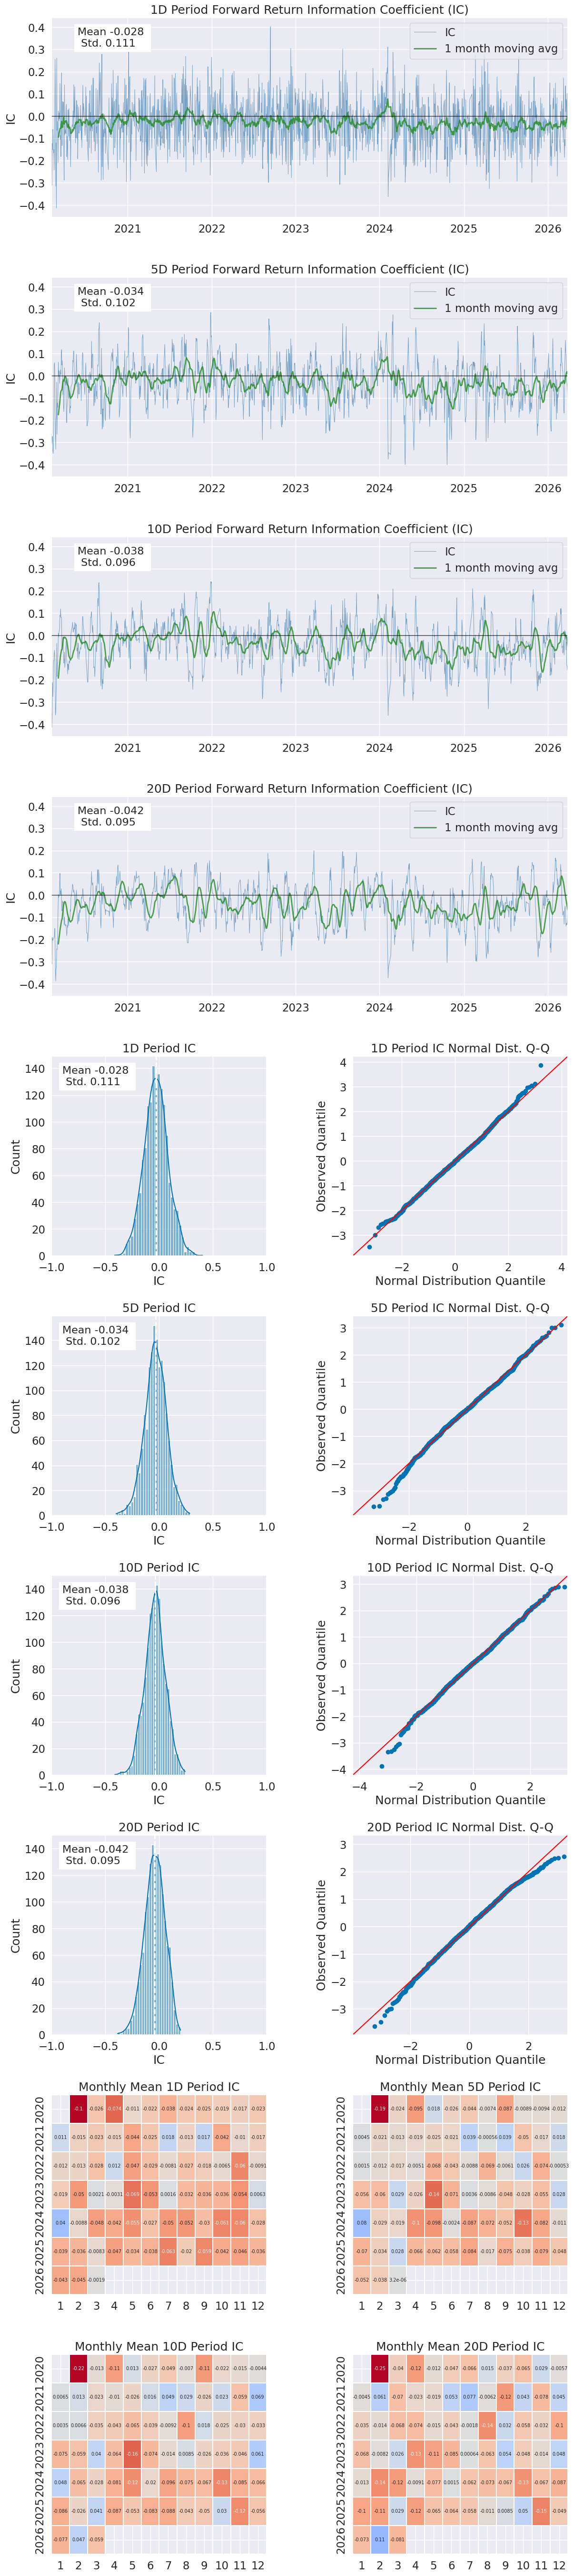

In [7]:
if HAS_ALPHALENS:
    # IC 分析：看因子值与未来收益的横截面相关性
    al.tears.create_information_tear_sheet(factor_data)
else:
    print("Alphalens 不可用，跳过 information tear sheet。")

Returns Analysis


,1D,5D,10D,20D
Ann. alpha,-0.141,-0.105,-0.096,-0.080
beta,-0.008,-0.016,-0.006,-0.003
Mean Period Wise Return Top Quantile (bps),-9.867,-8.040,-7.004,-5.860
Mean Period Wise Return Bottom Quantile (bps),-1.980,-1.803,-1.624,-1.369
Mean Period Wise Spread (bps),-7.887,-6.281,-5.411,-4.517


<Figure size 640x480 with 0 Axes>

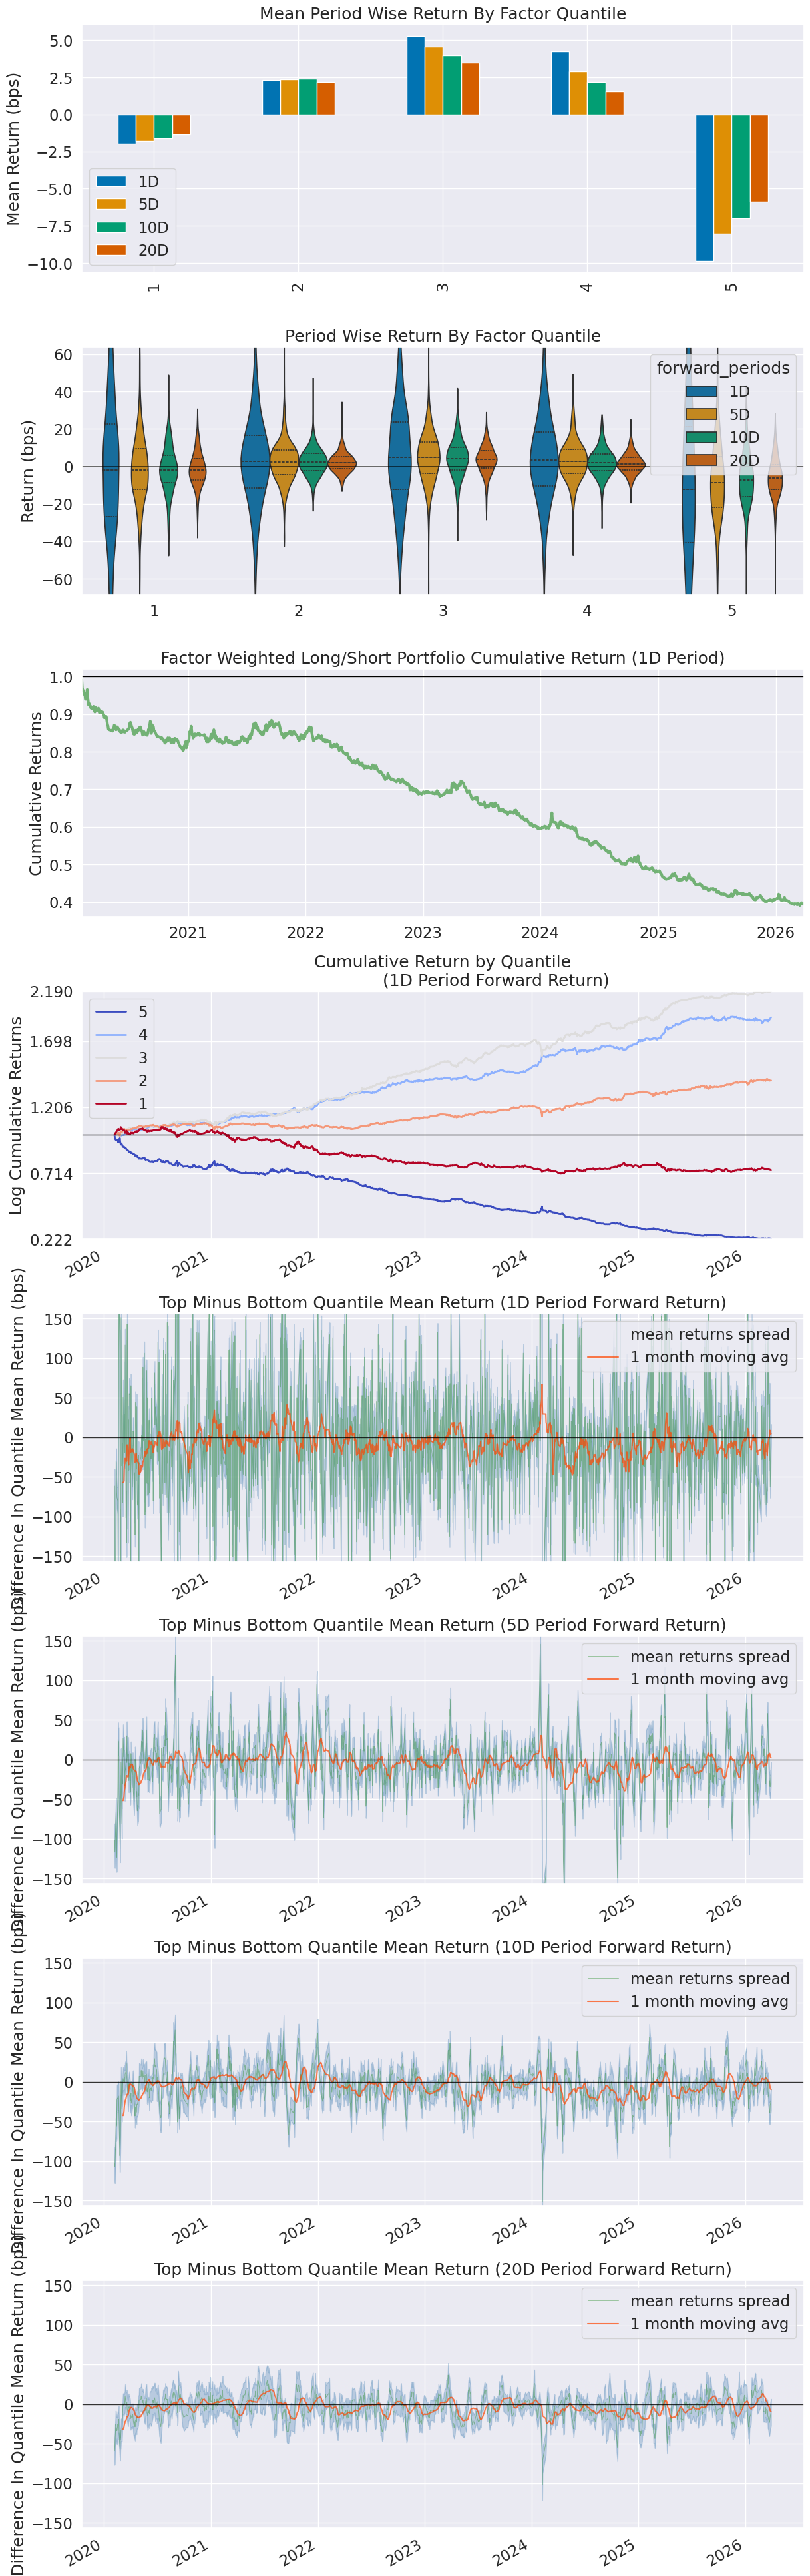

In [8]:
if HAS_ALPHALENS:
    # 收益分析：看不同分位数组合的未来收益表现
    al.tears.create_returns_tear_sheet(factor_data)
else:
    print("Alphalens 不可用，跳过 returns tear sheet。")

Turnover Analysis


,1D,5D,10D,20D
Quantile 1 Mean Turnover,0.117,0.433,0.678,0.754
Quantile 2 Mean Turnover,0.257,0.624,0.765,0.802
Quantile 3 Mean Turnover,0.276,0.591,0.672,0.692
Quantile 4 Mean Turnover,0.250,0.613,0.759,0.788
Quantile 5 Mean Turnover,0.112,0.433,0.703,0.789


,1D,5D,10D,20D
Mean Factor Rank Autocorrelation,0.94,0.514,0.014,-0.143


<Figure size 640x480 with 0 Axes>

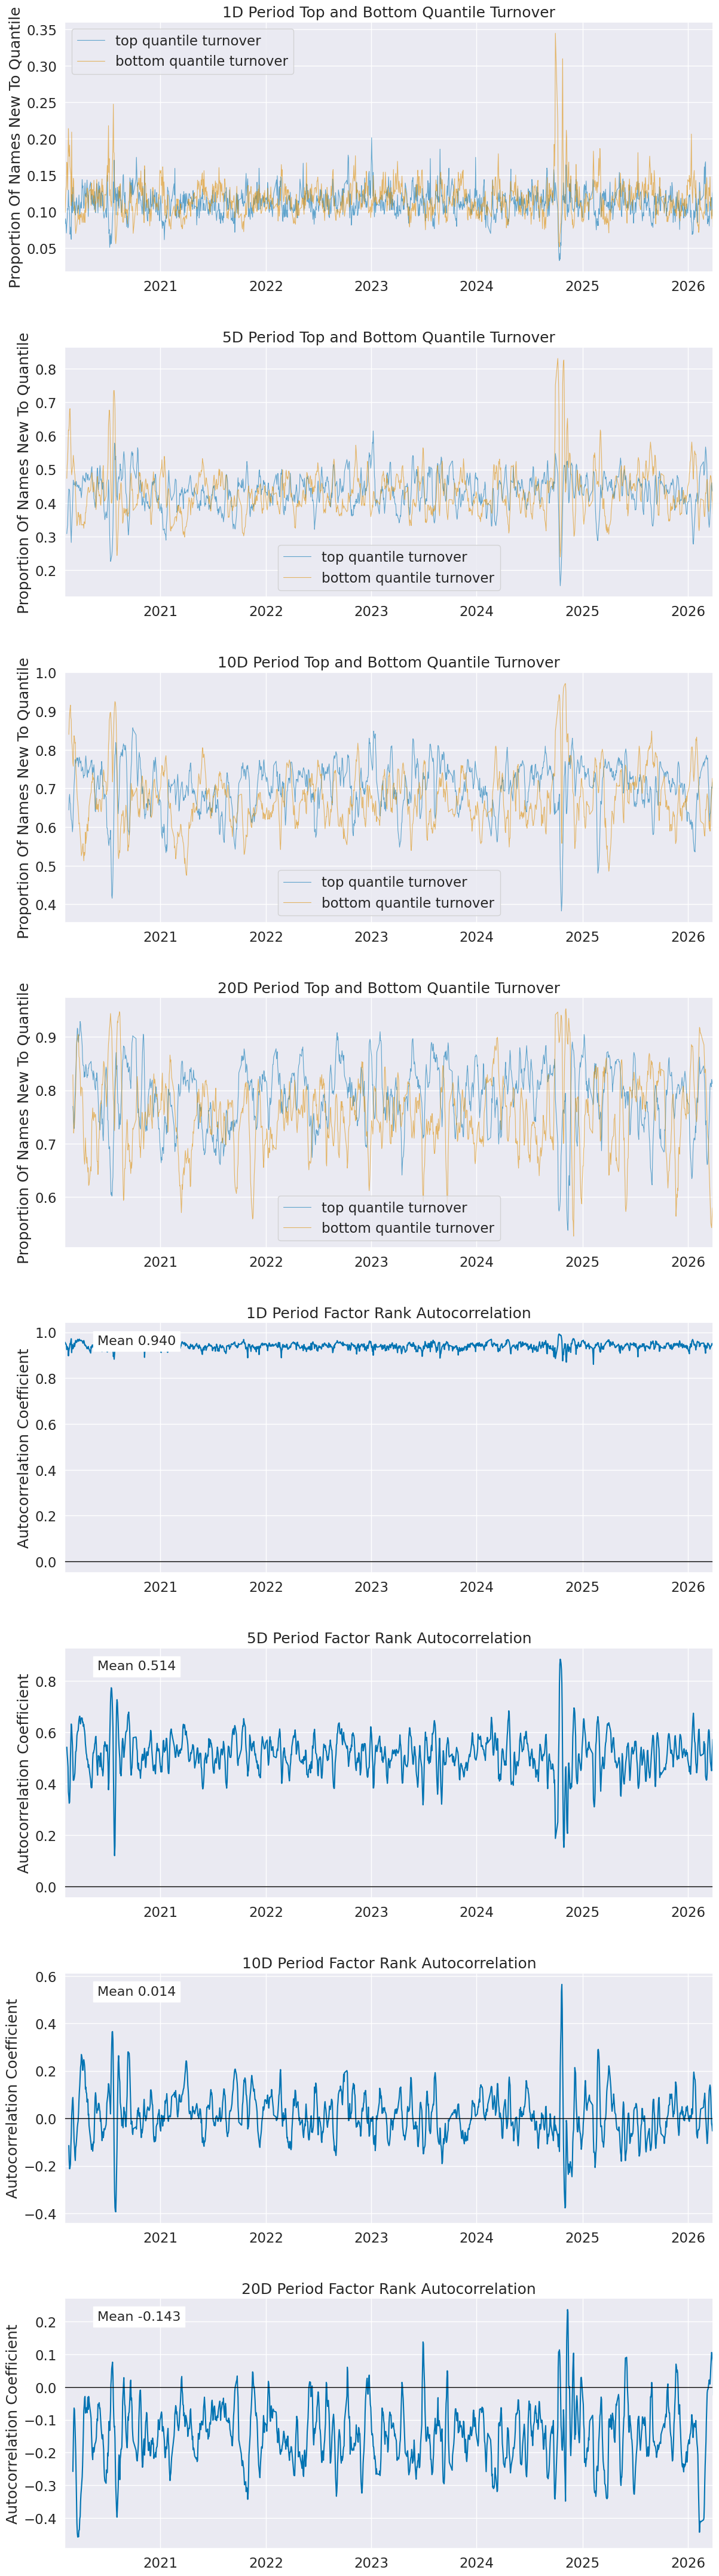

In [9]:
if HAS_ALPHALENS:
    # 换手分析：看因子分组是否过于频繁变化
    al.tears.create_turnover_tear_sheet(factor_data)
else:
    print("Alphalens 不可用，跳过 turnover tear sheet。")

## 6. Pandas 备用分析：IC / Rank IC

这一节不依赖 Alphalens。

计算逻辑：

1. 对每个未来窗口 `p`，计算未来 `p` 日收益：`close.pct_change(p).shift(-p)`。
2. 每个交易日横截面上，计算因子值和未来收益的相关系数。
3. Pearson 相关对应 IC；Spearman 相关对应 Rank IC。

In [ ]:
def calc_forward_returns(prices: pd.DataFrame, periods) -> dict:
    """计算多个持有期的未来收益矩阵。"""
    return {p: prices.pct_change(p).shift(-p) for p in periods}


def calc_daily_ic(factor_wide: pd.DataFrame, forward_return_wide: pd.DataFrame) -> pd.DataFrame:
    """逐日计算 IC 和 Rank IC。"""
    rows = []
    for dt in factor_wide.index.intersection(forward_return_wide.index):
        df = pd.DataFrame({
            "factor": factor_wide.loc[dt],
            "forward_return": forward_return_wide.loc[dt],
        }).dropna()
        if len(df) < 30:
            continue
        rows.append({
            "date": dt,
            "ic": df["factor"].corr(df["forward_return"], method="pearson"),
            "rank_ic": df["factor"].corr(df["forward_return"], method="spearman"),
            "count": len(df),
        })
    return pd.DataFrame(rows).set_index("date")


forward_returns = calc_forward_returns(close, FORWARD_PERIODS)
ic_results = {}

for p, fwd_ret in forward_returns.items():
    ic_results[p] = calc_daily_ic(factor_wide, fwd_ret)

# 汇总 IC 统计
ic_summary_rows = []
for p, ic_df in ic_results.items():
    ic_summary_rows.append({
        "period": p,
        "ic_mean": ic_df["ic"].mean(),
        "ic_std": ic_df["ic"].std(),
        "ic_t_stat": ic_df["ic"].mean() / ic_df["ic"].std() * np.sqrt(len(ic_df)),
        "rank_ic_mean": ic_df["rank_ic"].mean(),
        "rank_ic_std": ic_df["rank_ic"].std(),
        "rank_ic_t_stat": ic_df["rank_ic"].mean() / ic_df["rank_ic"].std() * np.sqrt(len(ic_df)),
        "positive_rank_ic_ratio": (ic_df["rank_ic"] > 0).mean(),
        "days": len(ic_df),
    })

ic_summary = pd.DataFrame(ic_summary_rows).set_index("period")
display(ic_summary)
ic_summary.to_csv(OUTPUT_DIR / f"ic_summary_window_{FACTOR_WINDOW}.csv", encoding="utf-8-sig")

In [ ]:
# 画出 Rank IC 时间序列和累计 Rank IC，观察稳定性
fig, axes = plt.subplots(len(FORWARD_PERIODS), 2, figsize=(14, 3.2 * len(FORWARD_PERIODS)))
if len(FORWARD_PERIODS) == 1:
    axes = np.array([axes])

for row, p in enumerate(FORWARD_PERIODS):
    ic_df = ic_results[p]
    ic_df["rank_ic"].plot(ax=axes[row, 0], title=f"{p}日 Rank IC")
    ic_df["rank_ic"].cumsum().plot(ax=axes[row, 1], title=f"{p}日 累计 Rank IC")
    axes[row, 0].axhline(0, color="black", linewidth=1)
    axes[row, 1].axhline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

## 7. Pandas 备用分析：分位数组合收益

这里按每日因子值把股票分成 `QUANTILES` 组，然后观察每组未来收益。

如果因子有效，通常希望看到：

- 高分位组和低分位组收益存在明显差异。
- 分位数组合收益具有一定单调性。
- Top - Bottom 多空收益在多个持有期下稳定。

In [ ]:
def assign_daily_quantiles(factor_row: pd.Series, quantiles: int) -> pd.Series:
    """对单日横截面因子分组。重复值过多时 qcut 可能失败，此时返回空分组。"""
    factor_row = factor_row.dropna()
    if len(factor_row) < quantiles * 10:
        return pd.Series(dtype=float)
    try:
        return pd.qcut(factor_row, quantiles, labels=False, duplicates="drop") + 1
    except ValueError:
        return pd.Series(dtype=float)


def calc_quantile_forward_returns(factor_wide: pd.DataFrame, forward_return_wide: pd.DataFrame, quantiles: int) -> pd.DataFrame:
    """计算每日每个分位数组的平均未来收益。"""
    rows = []
    for dt in factor_wide.index.intersection(forward_return_wide.index):
        q = assign_daily_quantiles(factor_wide.loc[dt], quantiles)
        if q.empty:
            continue
        fwd = forward_return_wide.loc[dt].reindex(q.index)
        df = pd.DataFrame({"quantile": q, "forward_return": fwd}).dropna()
        if df.empty:
            continue
        grouped = df.groupby("quantile")["forward_return"].mean()
        row = {"date": dt}
        for quantile, value in grouped.items():
            row[int(quantile)] = value
        rows.append(row)
    return pd.DataFrame(rows).set_index("date").sort_index()


quantile_results = {}
quantile_summary_rows = []

for p, fwd_ret in forward_returns.items():
    qret = calc_quantile_forward_returns(factor_wide, fwd_ret, QUANTILES)
    quantile_results[p] = qret
    mean_by_quantile = qret.mean()
    long_short = qret[QUANTILES] - qret[1]
    quantile_summary_rows.append({
        "period": p,
        "bottom_mean": mean_by_quantile.get(1, np.nan),
        "top_mean": mean_by_quantile.get(QUANTILES, np.nan),
        "top_minus_bottom_mean": long_short.mean(),
        "top_minus_bottom_t_stat": long_short.mean() / long_short.std() * np.sqrt(long_short.count()),
        "positive_long_short_ratio": (long_short > 0).mean(),
        "days": len(qret),
    })

quantile_summary = pd.DataFrame(quantile_summary_rows).set_index("period")
display(quantile_summary)
quantile_summary.to_csv(OUTPUT_DIR / f"quantile_summary_window_{FACTOR_WINDOW}.csv", encoding="utf-8-sig")

In [ ]:
# 画出各持有期下的平均分位收益柱状图
fig, axes = plt.subplots(1, len(FORWARD_PERIODS), figsize=(4.5 * len(FORWARD_PERIODS), 4), sharey=False)
if len(FORWARD_PERIODS) == 1:
    axes = [axes]

for ax, p in zip(axes, FORWARD_PERIODS):
    mean_by_quantile = quantile_results[p].mean()
    mean_by_quantile.plot(kind="bar", ax=ax, title=f"{p}日平均分位收益")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("因子分位组")
    ax.set_ylabel("未来收益")

plt.tight_layout()
plt.show()

## 8. Top / Bottom 分组换手分析

成交额类因子可能变化很快，所以要关注换手。

这里用一个简单定义：

```text
turnover = 1 - 当天分组与前一天分组的重合比例
```

换手越高，说明交易成本越重要。即使 IC 看起来不错，也可能被成本吃掉。

In [ ]:
def calc_group_turnover(factor_wide: pd.DataFrame, quantiles: int, target_quantile: int) -> pd.Series:
    """计算指定分位组的逐日换手率。"""
    previous_assets = None
    rows = []
    for dt in factor_wide.index:
        q = assign_daily_quantiles(factor_wide.loc[dt], quantiles)
        current_assets = set(q[q == target_quantile].index)
        if previous_assets is not None and previous_assets:
            overlap = len(current_assets.intersection(previous_assets))
            turnover = 1 - overlap / len(previous_assets)
            rows.append((dt, turnover))
        previous_assets = current_assets
    return pd.Series(dict(rows), name=f"Q{target_quantile}_turnover").sort_index()


bottom_turnover = calc_group_turnover(factor_wide, QUANTILES, 1)
top_turnover = calc_group_turnover(factor_wide, QUANTILES, QUANTILES)

turnover_summary = pd.DataFrame({
    "bottom_turnover_mean": [bottom_turnover.mean()],
    "top_turnover_mean": [top_turnover.mean()],
    "bottom_turnover_median": [bottom_turnover.median()],
    "top_turnover_median": [top_turnover.median()],
})

display(turnover_summary)
turnover_summary.to_csv(OUTPUT_DIR / f"turnover_summary_window_{FACTOR_WINDOW}.csv", index=False, encoding="utf-8-sig")

In [ ]:
plt.figure(figsize=(12, 4))
top_turnover.rolling(20).mean().plot(label=f"Top Q{QUANTILES} 20日平均换手")
bottom_turnover.rolling(20).mean().plot(label="Bottom Q1 20日平均换手")
plt.axhline(0, color="black", linewidth=1)
plt.title("Top / Bottom 分位组换手率")
plt.legend()
plt.show()

## 9. 多窗口对比

单个 `FACTOR_WINDOW` 只能回答某一个参数是否有效。

为了判断参数稳定性，可以对多个窗口重复计算 IC 摘要。

建议先比较：

```text
5, 10, 20, 40, 60, 120
```

如果某一段窗口附近都表现较好，说明因子更稳；如果只有一个窗口特别好，可能是样本内噪声。

In [ ]:
# 多窗口对比会比较耗时，可以按需打开更多窗口
WINDOW_LIST = [5, 10, 20, 40, 60, 120]

multi_window_rows = []

for window in WINDOW_LIST:
    print(f"计算窗口 {window}...")
    factor_raw = calc_linearreg_slope(turnover, window)
    factor_z = factor_raw.sub(factor_raw.mean(axis=1), axis=0)
    factor_z = factor_z.div(factor_z.std(axis=1), axis=0)
    factor_z = factor_z.replace([np.inf, -np.inf], np.nan)

    for p, fwd_ret in forward_returns.items():
        ic_df = calc_daily_ic(factor_z, fwd_ret)
        multi_window_rows.append({
            "window": window,
            "period": p,
            "rank_ic_mean": ic_df["rank_ic"].mean(),
            "rank_ic_t_stat": ic_df["rank_ic"].mean() / ic_df["rank_ic"].std() * np.sqrt(len(ic_df)),
            "positive_rank_ic_ratio": (ic_df["rank_ic"] > 0).mean(),
            "days": len(ic_df),
        })

multi_window_summary = pd.DataFrame(multi_window_rows)
display(multi_window_summary.pivot(index="window", columns="period", values="rank_ic_mean"))
multi_window_summary.to_csv(OUTPUT_DIR / "multi_window_ic_summary.csv", index=False, encoding="utf-8-sig")

## 10. 如何解读结果

建议按以下顺序判断这个因子是否值得继续做策略化：

1. **Rank IC 是否稳定**：均值不一定要很大，但方向要稳定，t 值要能站得住。
2. **分位收益是否单调**：Top 组和 Bottom 组之间最好有明显差异。
3. **Top - Bottom 是否稳健**：如果多空收益只靠少数日期贡献，要谨慎。
4. **换手是否过高**：成交额斜率因子可能很活跃，成本影响不能忽视。
5. **窗口是否稳定**：如果 20、40、60 都有效，比只有 37 有效更可信。
6. **方向是否正确**：成交额放大可能代表资金流入，也可能代表恐慌放量，所以要同时关注正向和反向表现。

如果 Alphalens 分析发现因子本身有稳定横截面预测力，下一步建议做 walk-forward：

```text
训练期选参数 -> 测试期验证 -> 滚动前进
```

这样可以检验当前 vectorbt 样本内参数寻优是否真的有前向有效性。